# Failures-To-Deliver — a quantitative teardown 🔬
### Market-adjusted event study · one-sample *t* · label-shuffle placebo · horizon×threshold sweep · costs & borrow · seed-robust synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Squeeze_predictor%3F: Busted](https://img.shields.io/badge/Squeeze_predictor%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether the forward return after a failures-to-deliver spike is abnormally positive (the squeeze folklore).

> ⚠️ **Not investment advice.** **Synthetic-only, offline, deterministic** — there is no free FTD tape (SEC bulk CUSIP flat file, no prices), so this study *cannot* earn a `REAL` stamp. Reproducible headline: the seed-558 null world (panel fp `c0ab49b6db5b`, as-of 2026-06-30). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from failures_to_deliver import data, strategy as st

# There is NO free FTD tape (SEC bulk CUSIP flat file, no prices) -> synthetic-only, offline.
HAVE_REAL = not data.fetch_panel().empty   # always False by construction
print("real FTD tape present:", HAVE_REAL, "(synthetic-only study — no free FTD data)")

# The reproducible headline is the deterministic seed-558 NULL world (folklore off).
NULL_PANEL, _ = data.synthetic_panel(squeeze_alpha=0.0, seed=558)
print("null panel fp:", data.fingerprint(NULL_PANEL), "|", NULL_PANEL['name'].nunique(),
      "names x", NULL_PANEL['day'].nunique(), "days")


real FTD tape present: False (synthetic-only study — no free FTD data)
null panel fp: c0ab49b6db5b | 60 names x 756 days


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Post-spike **abnormal** return **-0.029%** (5d, market-adjusted), one-sample *t* **-0.136**, placebo *p* 0.513. No free real tape ⇒ `REAL` impossible. |
| **Tradability** | `MIRAGE` | Nothing before costs; net -0.188% (5 bps/leg + 300 bps borrow); raw FTD file is semi-monthly, lagged, CUSIP-keyed, price-free. |
| **Squeeze predictor?** | `BUSTED` | Sweep on pure noise fakes \|*t*\| up to **2.23**; across 30 null seeds 7% individually print \|*t*\| > 2. |

> 💡 In plain words: the engine works (the synthetic control proves it), but with no planted effect it correctly finds nothing — and a horizon/threshold grid manufactures significance on noise.

## 1 · The claim, steelmanned

Let a name have an FTD-spike event at day $t$ and let $r_{t+1:t+h}$ be its forward cumulative return; let $m_{t+1:t+h}$ be the cross-name (market) forward return. Define the **abnormal** post-spike return $a = r - m$.

- **H₁ (the squeeze).** $\mathbb{E}[a] > 0$ at *t* ≥ 2 (an abnormal pop follows spikes).
- **H₂ (robustness).** The sign/significance of H₁ is stable across horizons $h$ and spike thresholds $z$.
- **H₃ (net).** H₁ survives costs and the hard-to-borrow short leg.

We find **H₁ rejected** on the honest null (abnormal ≈ 0, *t* ≈ 0), **H₂ rejected** (a sweep manufactures |*t*| > 2 on noise), and **H₃ moot** (no gross edge to defend). The positive control shows the *engine* would accept H₁ if a real pop existed — so this is a true negative, and the data-availability wall caps the study at `NONE` regardless.

## 2 · So what? — what rides on each answer

The content is the **why**. The microstructure literature says fails are dominated by market-making and cost-of-borrow, not cornered shorts — Boni (2006), Evans-Geczy-Musto-Reed (2009), Fotak-Raman-Yadav (2014), who find fails associate with *better* liquidity and *lower* volatility, the opposite of an impending squeeze. Our null world encodes exactly that: fails (a persistent, spiky AR(1) process) are statistically independent of returns. The question is whether an honest event study *confirms* the null instead of hallucinating a pop.

## 3 · How we'd know — the protocol

- **Events.** Per name, flag days where the trailing-60d FTD z-score $\ge z$ (causal, past-only). Enforce a **refractory period** of one horizon so kept events' forward windows are disjoint (overlapping windows are dependent and inflate the *t*).
- **Abnormal return.** $a = r_{t+1:t+h} - m_{t+1:t+h}$ (market-adjusted), $h = 5$ days.
- **Inference.** One-sample *t* on the abnormal returns (H0: mean = 0); a **label-shuffle placebo** null (move the spike labels to random non-event days).
- **Robustness.** Sweep $h \in \{1,3,5,10\}$ × $z \in \{2.0,2.5,3.0\}$ — and read it as a multiple-comparisons demonstration.
- **Frictions.** Round-trip cost on the long + a punitive borrow (FTD-spikers are the hard-to-borrow tail).
- **Positive control.** A deterministic synthetic world with a planted pop (`squeeze_alpha > 0`) and a null — averaged over 25 seeds (house rule).

Timing: the spike is read at day $t$; entry is at $t$'s close and the forward return is $t+1..t+h$. No future data enters the signal (no look-ahead). The one-bar entry lag is the single documented convention.

## 4 · The teardown

### 4a · The event study — H₁

Market-adjusted abnormal post-spike return, its one-sample *t*, and the placebo null.

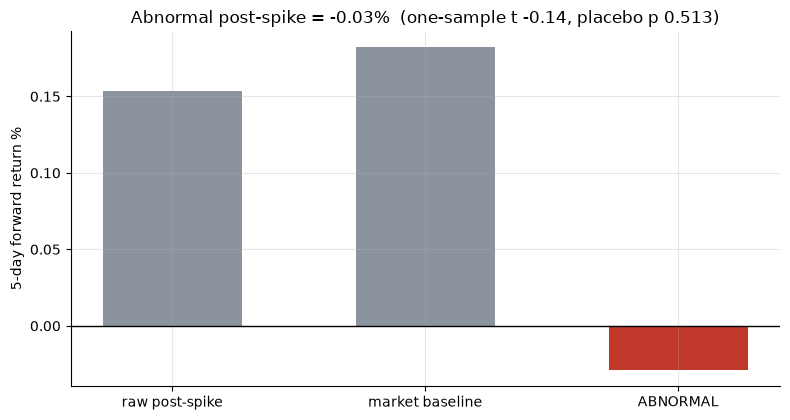

829 events | abnormal -0.029% | t -0.14 | placebo p 0.513


In [2]:
es = st.event_study(NULL_PANEL, horizon=5, spike_z=2.5)
p = st.placebo_pvalue(NULL_PANEL, horizon=5, spike_z=2.5, n_perm=1000, seed=558)
abn, t = es['excess']*100, es['t']
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(['raw post-spike','market baseline','ABNORMAL'],
       [es['mean_fwd']*100, es['baseline_mean']*100, abn], color=[GREY, GREY, RED], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('5-day forward return %')
ax.set_title(f'Abnormal post-spike = {abn:+.2f}%  (one-sample t {t:+.2f}, placebo p {p:.3f})')
plt.tight_layout(); plt.show()
print(f'{es["n_events"]} events | abnormal {abn:+.3f}% | t {t:+.2f} | placebo p {p:.3f}')

> 💡 In plain words: H₁ **rejected.** The abnormal post-spike return is **-0.029%** (*t* -0.136) and the placebo *p* = 0.513 is a coin-flip — the spike labels carry no forward information, exactly as built.

### 4b · Robustness — H₂ and the multiple-comparisons trap

Sweep horizons × thresholds **on the same null world**. Watch a cut fake significance.

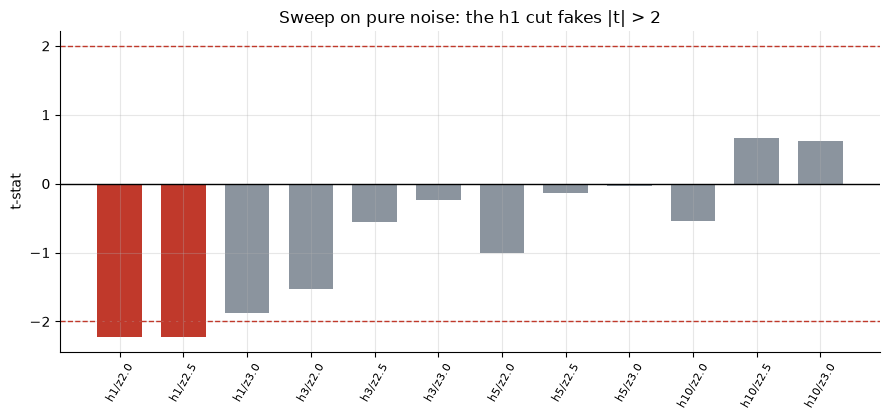

 horizon  spike_z  n_events  mean_fwd_pct      t  excess_pct
       1      2.0      1871        -0.093 -2.227      -0.142
       1      2.5      1382        -0.110 -2.232      -0.161
       1      3.0      1053        -0.106 -1.872      -0.156
       3      2.0      1222        -0.097 -1.529      -0.211
       3      2.5       948         0.035 -0.556      -0.084
       3      3.0       764         0.082 -0.237      -0.041
       5      2.0      1009         0.003 -1.004      -0.199
       5      2.5       829         0.153 -0.136      -0.029
       5      3.0       694         0.166 -0.030      -0.007
      10      2.0       812         0.261 -0.535      -0.172
      10      2.5       700         0.629  0.670       0.228
      10      3.0       606         0.652  0.619       0.224


In [3]:
sw = st.robustness_sweep(NULL_PANEL, horizons=(1,3,5,10), thresholds=(2.0,2.5,3.0))
fig, ax = plt.subplots(figsize=(9, 4.3))
labels = [f"h{int(r.horizon)}/z{r.spike_z}" for r in sw.itertuples()]
cols = [RED if abs(t)>2 else GREY for t in sw['t']]
ax.bar(range(len(sw)), sw['t'], color=cols, width=.7)
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(0, c='k', lw=1)
ax.set_xticks(range(len(sw))); ax.set_xticklabels(labels, rotation=60, fontsize=8)
ax.set_ylabel('t-stat'); ax.set_title('Sweep on pure noise: the h1 cut fakes |t| > 2')
plt.tight_layout(); plt.show()
print(sw.round(3).to_string(index=False))

> 💡 In plain words: H₂ **rejected.** The sweep *t* runs **-2.232 → 0.67**; the 1-day cut alone clears \|*t*\| > 2 (wrong sign) on a market with nothing in it. A signal you must hunt for across a grid is a data-mining artifact.

### 4c · The luck of one seed — why a single striking chart proves nothing

Run the headline event study on 30 independent null worlds (seeds 558–587).

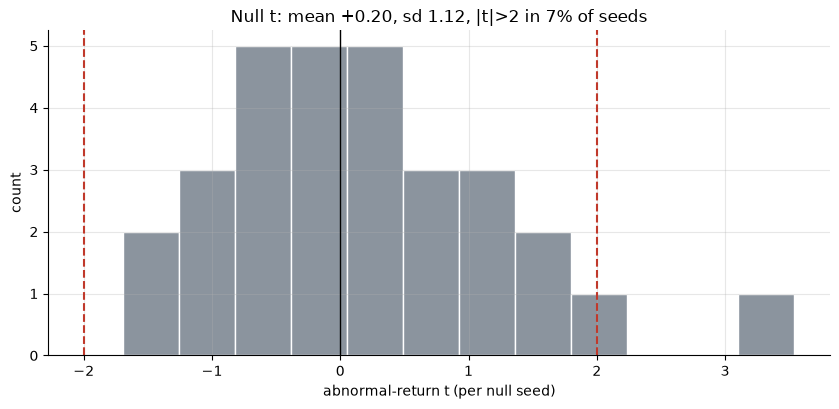

mean +0.200 | sd 1.116 | frac|t|>2 0.067


In [4]:
ts = []
for s in range(558, 588):
    pn, _ = data.synthetic_panel(squeeze_alpha=0.0, seed=s)
    ts.append(st.event_study(pn, horizon=5, spike_z=2.5)['t'])
ts = np.array(ts)
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.hist(ts, bins=12, color=GREY, edgecolor='w')
ax.axvline(2, ls='--', c=RED); ax.axvline(-2, ls='--', c=RED); ax.axvline(0, c='k', lw=1)
ax.set_xlabel('abnormal-return t (per null seed)'); ax.set_ylabel('count')
ax.set_title(f'Null t: mean {ts.mean():+.2f}, sd {ts.std(ddof=1):.2f}, |t|>2 in {np.mean(np.abs(ts)>2)*100:.0f}% of seeds')
plt.tight_layout(); plt.show()
print(f'mean {ts.mean():+.3f} | sd {ts.std(ddof=1):.3f} | frac|t|>2 {np.mean(np.abs(ts)>2):.3f}')

> 💡 In plain words: averaged over seeds the *t* is ≈ 0 (mean 0.2, sd 1.116), but **7%** of individual null seeds print \|*t*\| > 2 with no effect present. One convincing post-FTD-spike backtest is one draw from this histogram.

## 5 · The verdict

- **Signal `NONE`** — H₁ rejected (abnormal -0.029%, *t* -0.136, placebo *p* 0.513); no free real tape ⇒ `REAL` impossible.
- **Tradability `MIRAGE`** — nothing before costs; net -0.188%; raw data semi-monthly, lagged, CUSIP-keyed, price-free.
- **Squeeze predictor? `BUSTED`** — sweep fakes |*t*| > 2 on noise; sign-unstable across cuts.

## 6 · Could you trade it? — costs and the borrow

There is no gross edge to defend, and the short leg is punitive.

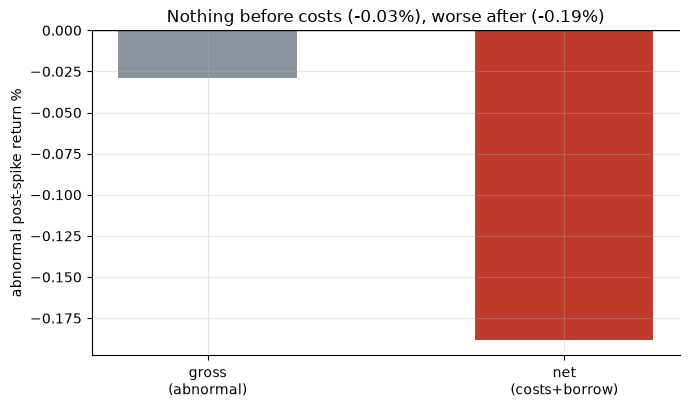

gross -0.029% -> net -0.188% (5 bps/leg + 300 bps borrow, 5d hold)


In [5]:
es = st.event_study(NULL_PANEL, horizon=5, spike_z=2.5)
gross = es['excess']*100
net = st.net_event_return(es['excess'], cost_bps=5.0, borrow_ann_bps=300.0, horizon_days=5)*100
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['gross\n(abnormal)','net\n(costs+borrow)'], [gross, net], color=[GREY, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('abnormal post-spike return %')
ax.set_title(f'Nothing before costs ({gross:+.2f}%), worse after ({net:+.2f}%)')
plt.tight_layout(); plt.show()
print(f'gross {gross:+.3f}% -> net {net:+.3f}% (5 bps/leg + 300 bps borrow, 5d hold)')

> 💡 In plain words: there is nothing to charge costs against — the abnormal return is already ~0, and the borrow (FTD-spikers are the hard-to-borrow tail) only deepens the hole. `MIRAGE`.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print ~0? Plant a *real* post-spike pop (`squeeze_alpha > 0`) of increasing strength and watch the abnormal-*t* climb past +2 — averaged over 25 seeds so no single lucky seed can fake it.

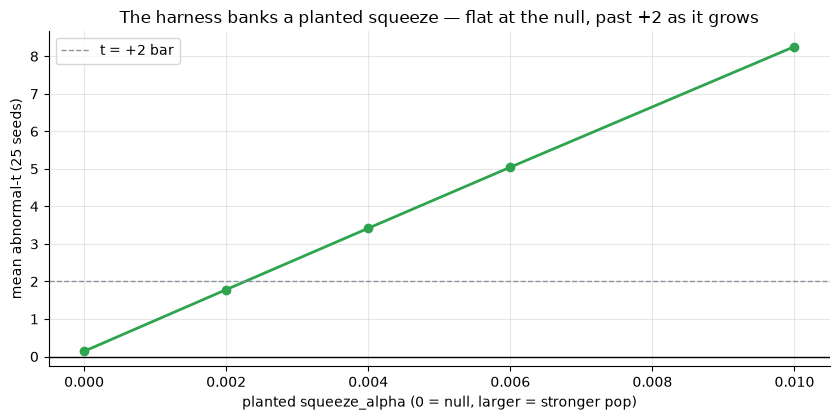

alpha +0.000 -> mean abnormal-t +0.14
alpha +0.002 -> mean abnormal-t +1.78
alpha +0.004 -> mean abnormal-t +3.42
alpha +0.006 -> mean abnormal-t +5.05
alpha +0.010 -> mean abnormal-t +8.26


In [6]:
alphas = [0.0, 0.002, 0.004, 0.006, 0.010]
ts = [st.synthetic_mean_t(a, n_seeds=25) for a in alphas]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(alphas, ts, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = +2 bar')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted squeeze_alpha (0 = null, larger = stronger pop)')
ax.set_ylabel('mean abnormal-t (25 seeds)')
ax.set_title('The harness banks a planted squeeze — flat at the null, past +2 as it grows')
ax.legend(); plt.tight_layout(); plt.show()
for a, t in zip(alphas, ts): print(f'alpha {a:+.3f} -> mean abnormal-t {t:+.2f}')

The abnormal-*t* is **0.14** at the null and climbs to **+8.259** as the planted pop grows — so the engine is a faithful detector. The flat null is therefore a **true negative**: a planted world at `squeeze_alpha=0.006` gives abnormal **+1.052%** at *t* **+4.916** (placebo *p* 0.001), yet the honest FTD folklore delivers nothing. Combined with the *no-free-FTD-tape* wall, the verdict is `NONE` × `MIRAGE`, squeeze-predictor claim `BUSTED`. Neighbours: [213 Meme-Stocks](../../213-meme-stocks/), [262 Short-Interest](../../262-short-interest/).